## Preprocessing Data

In [42]:
import pandas as pd

data = pd.read_csv("dataset/dataset.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7657 non-null   object
dtypes: object(1)
memory usage: 59.9+ KB


,text
0,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK
4,parah parah pejabat indonesiaa


In [43]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    7657 non-null   object
dtypes: object(1)
memory usage: 59.9+ KB


,text
0,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK
4,parah parah pejabat indonesiaa


In [44]:
## Cleaning

import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

data['cleaning'] = data['text'].apply(lambda x: remove_URL(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_usernames(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_html(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_emoji(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_symbols(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_numbers(x))

data.head(5)

,text,cleaning
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [45]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

data['case_folding'] = data['cleaning'].apply(case_folding)
data.head(5)

,text,cleaning,case_folding
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [46]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(data[['text','cleaning','case_folding']])
data.head()

,text,cleaning,case_folding
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [47]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [48]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['text','cleaning','case_folding','normalisasi']])
df.head(5)

,text,cleaning,case_folding,normalisasi
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa


In [49]:
## tokenisasi

def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,text,cleaning,case_folding,normalisasi,tokenize
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"[serius, bertanya, kalau, tidak, ada, dpr, sem..."
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"[menari, di, atas, penderitaan, rakyat]"
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]"
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"[tidak, usah, bayar, pajak, titikkkk]"
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,"[parah, parah, pejabat, indonesiaa]"


In [50]:
## stopword removal

from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sheva\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [51]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Ubah hasil list jadi string
df['stopword removal'] = df['tokenize'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

df.head(5)

,text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"[serius, bertanya, kalau, tidak, ada, dpr, sem...",serius dpr orang hidup
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"[menari, di, atas, penderitaan, rakyat]",menari penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"[dunia, akhirat, gue, tidak, iklas, byr, pajak]",dunia akhirat gue iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"[tidak, usah, bayar, pajak, titikkkk]",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,"[parah, parah, pejabat, indonesiaa]",parah parah pejabat indonesiaa


In [52]:
from collections import Counter

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

df_freq.to_csv('frekuensi_kata_awal.csv', index=False)
print("✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.")
df_freq.info()
df_freq.head(50)

✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Kata       9648 non-null   object
 1   Frekuensi  9648 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 150.9+ KB


,Kata,Frekuensi
0,dpr,1722
1,juta,1716
2,ya,1646
3,rakyat,1492
4,gaji,927
5,rumah,790
6,beras,790
7,tunjangan,757
8,anggota,536
9,orang,447


In [53]:
hapus_kata = ['ya','sih','tau','biar']

# hapus kata dari teks
df['stopword removal'] = df['stopword removal'].apply(
    lambda x: ' '.join([kata for kata in x.split() if kata not in hapus_kata]))

df['stopword removal'].str.contains('|'.join(hapus_kata)).sum()

np.int64(3852)

In [54]:
# ---  Membuat kamus kata tidak baku -> kata baku
kamus_tidak_baku = {
    'dpr':'dewan perwakilan rakyat'
}

def perbaiki_kata(teks):
    kata_list = teks.split()
    hasil = [kamus_tidak_baku.get(kata, kata) for kata in kata_list]
    return ' '.join(hasil)

df['stopword removal'] = df['stopword removal'].astype(str).apply(perbaiki_kata)


In [55]:
from collections import Counter
import re

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

# df_freq.info()
df_freq.head(50)

,Kata,Frekuensi
0,rakyat,3214
1,dewan,1887
2,perwakilan,1744
3,juta,1716
4,gaji,927
5,rumah,790
6,beras,790
7,tunjangan,757
8,anggota,536
9,orang,447


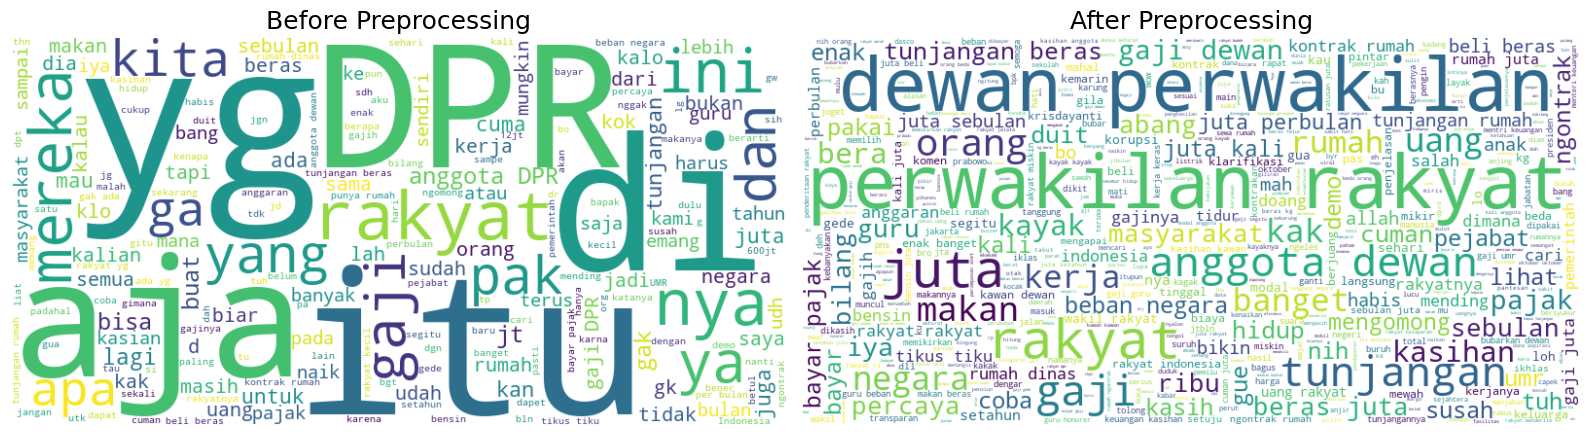

In [56]:
## wordcloud setelah preprocessing

import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# WordCloud Before
text_before = ' '.join(
    df['text']
    .astype(str)
    .tolist()
)

wc_before = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_before)

# WordCloud After (dari kolom 'stopword removal')
text_after = ' '.join(
    [" ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
     for x in df['stopword removal'].astype(str)]
)

wc_after = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=500,
    width=800,
    height=400
).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()

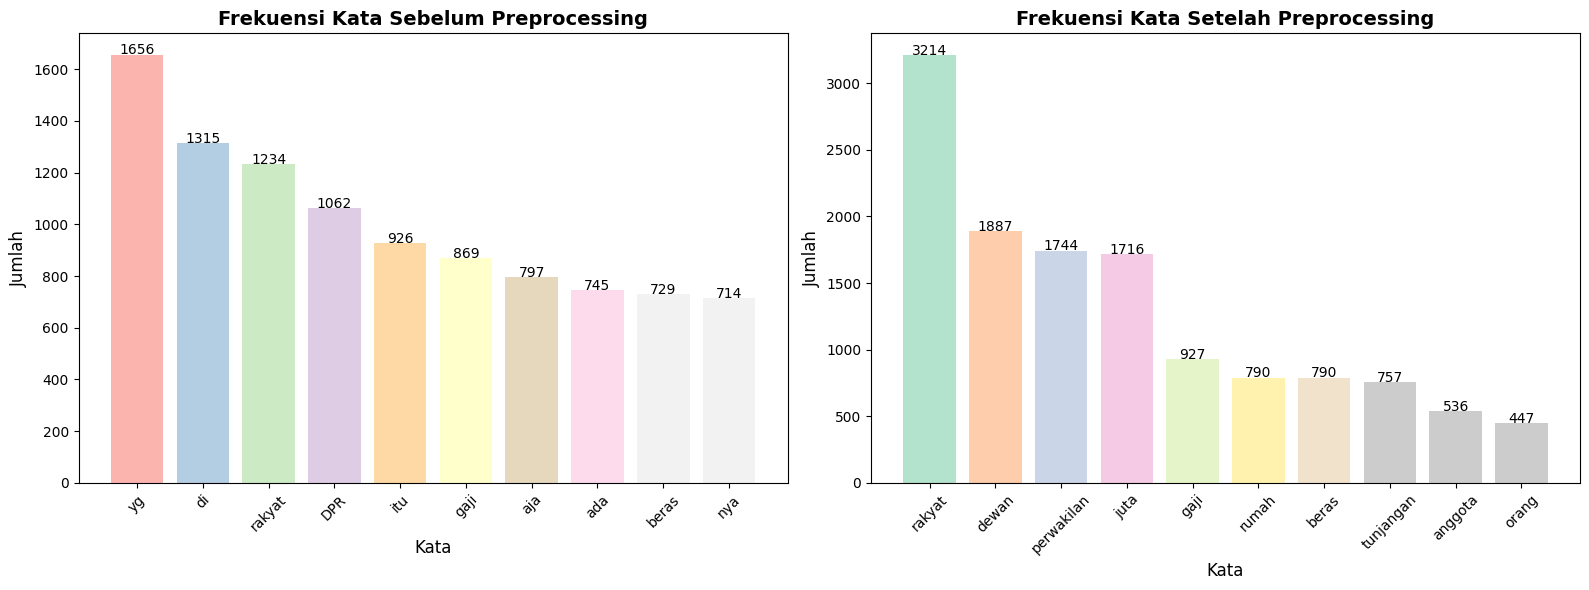

In [57]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS
import re

# Set stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi helper untuk membersihkan tanda kutip, [ ], , dll
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        # Hapus [ ], tanda petik tunggal/ganda, koma
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE
all_text_before = clean_text_column(df["text"])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# AFTER
all_text_after = clean_text_column(df["stopword removal"])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE Plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

# AFTER Plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

In [60]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);

In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   text                  7657 non-null   object
 1   cleaning              7657 non-null   object
 2   case_folding          7657 non-null   object
 3   normalisasi           7657 non-null   object
 4   Kata_Baku             7657 non-null   object
 5   Kata_Tidak_Baku       7657 non-null   object
 6   Kata_Tidak_Baku_Hash  7657 non-null   object
dtypes: object(7)
memory usage: 418.9+ KB


## Pelabelan

In [61]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7657 entries, 0 to 7656
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              7657 non-null   object
 1   cleaning          7657 non-null   object
 2   case_folding      7657 non-null   object
 3   normalisasi       7649 non-null   object
 4   tokenize          7657 non-null   object
 5   stopword removal  7623 non-null   object
dtypes: object(6)
memory usage: 359.1+ KB


,text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius nanya klo gak ada dpr semua orang masih...,serius bertanya kalau tidak ada dpr semua oran...,"['serius', 'bertanya', 'kalau', 'tidak', 'ada'...",serius dewan perwakilan rakyat orang hidup
1,Menari di atas penderitaan rakyat,Menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,menari di atas penderitaan rakyat,"['menari', 'di', 'atas', 'penderitaan', 'rakyat']",menari penderitaan rakyat
2,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas Byr pajak,dunia akhirat gw ga iklas byr pajak,dunia akhirat gue tidak iklas byr pajak,"['dunia', 'akhirat', 'gue', 'tidak', 'iklas', ...",dunia akhirat gue iklas byr pajak
3,GAK USAH BAYAR PAJAK... TITIKKKK,GAK USAH BAYAR PAJAK TITIKKKK,gak usah bayar pajak titikkkk,tidak usah bayar pajak titikkkk,"['tidak', 'usah', 'bayar', 'pajak', 'titikkkk']",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,parah parah pejabat indonesiaa,"['parah', 'parah', 'pejabat', 'indonesiaa']",parah parah pejabat indonesiaa


In [62]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7623 entries, 0 to 7656
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              7623 non-null   object
 1   cleaning          7623 non-null   object
 2   case_folding      7623 non-null   object
 3   normalisasi       7623 non-null   object
 4   tokenize          7623 non-null   object
 5   stopword removal  7623 non-null   object
dtypes: object(6)
memory usage: 416.9+ KB


In [63]:
data = pd.DataFrame(data[['stopword removal']])
data.head(5)

,stopword removal
0,serius dewan perwakilan rakyat orang hidup
1,menari penderitaan rakyat
2,dunia akhirat gue iklas byr pajak
3,bayar pajak titikkkk
4,parah parah pejabat indonesiaa


In [64]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['stopword removal'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(20)


,stopword removal,Score,Sentiment
0,serius dewan perwakilan rakyat orang hidup,-2,Negatif
1,menari penderitaan rakyat,-1,Negatif
2,dunia akhirat gue iklas byr pajak,-1,Negatif
3,bayar pajak titikkkk,-1,Negatif
4,parah parah pejabat indonesiaa,-3,Negatif
5,rakyat sengsara anggota dewan perwakilan rakya...,-3,Negatif
6,bantuan listrik sumpah allah sakit hati denger...,3,Positif
7,allah ikhlas dunia akhirat gaji dewan perwakil...,0,Netral
8,orang orang prabowo pejabat kayak rakyat sengsara,-3,Negatif
9,pantesan rebutan kursi dewan perwakilan rakyat...,-2,Negatif


C:\Users\sheva\AppData\Local\Temp\ipykernel_27172\3995538478.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


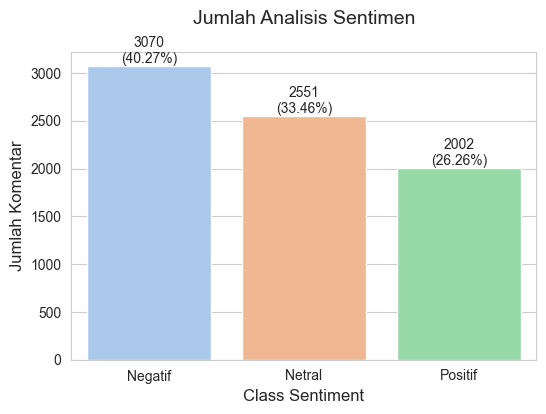

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [67]:
data.to_csv('Hasil_Labelling_Data_3class.csv',encoding='utf8', index=False)

## Wordcloud per Sentimen

Wordcloud dibuat menggunakan **bobot TF-IDF per sentimen** — ukuran kata mencerminkan seberapa khas kata tersebut
untuk sentimen tertentu, bukan sekadar frekuensi mentah. Kata yang muncul di semua sentimen (seperti `dpr`, `rakyat`, `juta`)
akan memiliki bobot rendah sehingga tidak mendominasi tampilan.

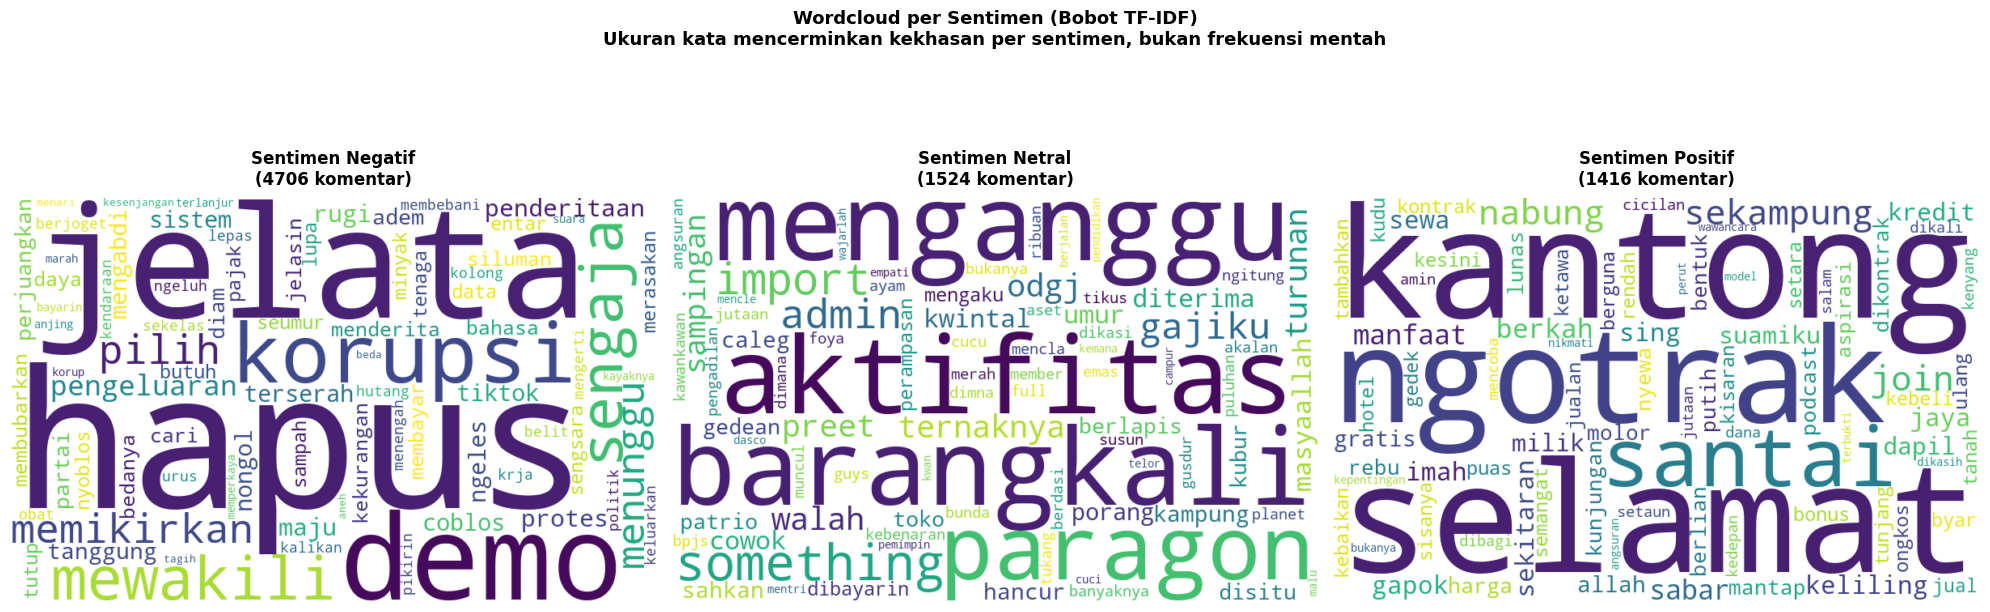

Wordcloud disimpan ke img/wordcloud_per_sentimen.png

Top 10 kata khas per sentimen:

  Negatif: ['hapus', 'jelata', 'demo', 'korupsi', 'mewakili', 'sengaja', 'memikirkan', 'pilih', 'menunggu', 'pengeluaran']

  Netral: ['barangkali', 'menganggu', 'aktifitas', 'paragon', 'something', 'import', 'admin', 'gajiku', 'odgj', 'preet']

  Positif: ['selamat', 'kantong', 'ngotrak', 'santai', 'nabung', 'join', 'sekampung', 'manfaat', 'sabar', 'berkah']


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud

# ── Load data ────────────────────────────────────────────────────────────────
df_wc = pd.read_csv('Hasil_Labelling_Data_3class.csv')
df_wc['stopword removal'] = df_wc['stopword removal'].fillna('')

# ── Noise words: kata terlalu umum lintas sentimen ───────────────────────────
NOISE_WC = {
    # Angka & nominal
    'juta','ribu','ratus','miliar','milyar','triliun','persen',
    'kali','sebulan','perbulan','setahun','pertahun','perhari',
    # Kata ganti
    'aku','saya','kamu','anda','dia','kita','kami','mereka',
    'gue','gw','gua','lo','lu','loe',
    # Partikel informal
    'ya','yaa','deh','sih','nih','tuh','dong','lah','kah',
    'nah','eh','ah','oh','wah','iya','yg','nya','si',
    'wkwk','wkwkwk','haha','hehe','hihi','huhu','hahaha',
    # Penghubung & preposisi
    'dan','atau','tapi','tetapi','namun','karena','jadi',
    'maka','agar','bahwa','kalau','kalo','jika','bila',
    'dari','untuk','dengan','kepada','oleh','pada',
    'ke','di','yang','ini','itu','sana','sini','situ',
    # Keterangan umum
    'sangat','banget','sekali','paling','lebih','kurang',
    'hanya','saja','aja','cuma','juga','pun','bahkan',
    'sudah','udah','belum','masih','lagi','terus','lalu',
    'bisa','boleh','harus','perlu','mau','ingin',
    'ada','tidak','tak','bukan','jangan','tanpa',
    'ga','gak','nggak','ngga','enggak','ndak','gakk',
    # Kata terlalu umum lintas sentimen
    'orang','rakyat','negara','indonesia','pemerintah','dpr',
    'anggota','wakil','dewan','pejabat','guru',
    'gaji','tunjangan','beras','rumah','uang','kerja',
    # Kata kerja bantu
    'adalah','ialah','merupakan','menjadi',
    'buat','bikin','kasih','beri','dapat','ambil',
    'tahu','tau','bilang','kata','lihat',
    'makan','minum','pergi','datang','balik',
    # Kata umum tidak diskriminatif
    'sama','seperti','kayak','gimana','bagaimana',
    'masa','sebenarnya','harusnya','coba',
    'banyak','sedikit','semua','seluruh','setiap',
    'besar','kecil','baik','buruk','benar','salah',
    'baru','lama','dulu','sekarang','nanti',
    'sering','jarang','selalu','kadang','pernah',
    'emang','memang','apalagi','bahkan','memangnya',
    # Typo / noise
    'byr','titikkkk','indonesiaa','pejabatt',
}

def get_word_freq(texts, noise):
    """Hitung frekuensi kata dengan deduplikasi teks identik."""
    text_counts = Counter(
        t.strip() for t in texts if isinstance(t, str) and t.strip()
    )
    freq = Counter()
    for text, count in text_counts.items():
        words = [
            w for w in text.split()
            if w not in noise
            and len(w) >= 4
            and not re.fullmatch(r'\d+', w)
            and not re.fullmatch(r'[a-z]{1,3}', w)
        ]
        freq.update({w: count for w in words})
    return freq

SENTIMENTS = ['Negatif', 'Netral', 'Positif']
raw_freqs = {}
for sent in SENTIMENTS:
    texts = df_wc[df_wc['Sentiment'] == sent]['stopword removal'].tolist()
    raw_freqs[sent] = get_word_freq(texts, NOISE_WC)

def compute_tfidf_weights(target, all_freqs, min_freq=3):
    """
    Hitung bobot TF-IDF per kata untuk sentimen target.
    Skor = freq_target / (1 + total_freq_sentimen_lain)
    Kata yang khas untuk satu sentimen akan memiliki skor tinggi.
    """
    others = [s for s in all_freqs if s != target]
    weights = {}
    for word, freq in all_freqs[target].items():
        if freq < min_freq:
            continue
        other_freq = sum(all_freqs[s].get(word, 0) for s in others)
        score = freq / (1 + other_freq)
        weights[word] = score
    return weights

# ── Visualisasi: style default WordCloud ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Wordcloud per Sentimen (Bobot TF-IDF)\n'
    'Ukuran kata mencerminkan kekhasan per sentimen, bukan frekuensi mentah',
    fontsize=13, fontweight='bold', y=1.02
)

TITLES = {'Negatif': 'Sentimen Negatif', 'Netral': 'Sentimen Netral', 'Positif': 'Sentimen Positif'}

for ax, sent in zip(axes, SENTIMENTS):
    weights = compute_tfidf_weights(sent, raw_freqs, min_freq=3)
    n_komentar = len(df_wc[df_wc['Sentiment'] == sent])

    wc = WordCloud(
        width=800,
        height=500,
        background_color='white',
        max_words=80,
        random_state=42,
        collocations=False,
    ).generate_from_frequencies(weights)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(
        f'{TITLES[sent]}\n({n_komentar} komentar)',
        fontsize=12, fontweight='bold', pad=10
    )

plt.tight_layout()
plt.savefig('img/wordcloud_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wordcloud disimpan ke img/wordcloud_per_sentimen.png')

# ── Print top 10 kata khas per sentimen ─────────────────────────────────────
print('\nTop 10 kata khas per sentimen:')
for sent in SENTIMENTS:
    weights = compute_tfidf_weights(sent, raw_freqs)
    top10 = sorted(weights.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f'\n  {sent}: {[w for w,_ in top10]}')


## Frekuensi Kata

In [75]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7623 entries, 0 to 7622
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  7623 non-null   object
 1   Score             7623 non-null   int64 
 2   Sentiment         7623 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.8+ KB


,stopword removal,Score,Sentiment
0,serius dewan perwakilan rakyat orang hidup,-2,Negatif
1,menari penderitaan rakyat,-1,Negatif
2,dunia akhirat gue iklas byr pajak,-1,Negatif
3,bayar pajak titikkkk,-1,Negatif
4,parah parah pejabat indonesiaa,-3,Negatif


In [76]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7623 entries, 0 to 7622
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   stopword removal  7623 non-null   object
 1   Score             7623 non-null   int64 
 2   Sentiment         7623 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.8+ KB


In [77]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,serius dewan perwakilan rakyat orang hidup,Negatif
1,menari penderitaan rakyat,Negatif
2,dunia akhirat gue iklas byr pajak,Negatif
3,bayar pajak titikkkk,Negatif
4,parah parah pejabat indonesiaa,Negatif


In [78]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from collections import Counter

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['stopword removal'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['stopword removal'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['stopword removal'].str.cat(sep=' ')

# Stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh'])

# Fungsi hitung frekuensi kata + tampilkan jumlah
def plot_word_freq(text, title, color):
    words = [w for w in text.split() if w not in stopwords]
    word_freq = Counter(words).most_common(10)  # ambil 10 kata teratas
    df_freq = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])

    plt.figure(figsize=(8,5))
    bars = plt.barh(df_freq['Kata'], df_freq['Frekuensi'], color=color)
    plt.gca().invert_yaxis()  # biar kata frekuensi tertinggi di atas
    plt.title(f"Top 10 Kata - Sentimen {title}", fontsize=14)
    plt.xlabel("Frekuensi")
    plt.ylabel("Kata")

    # Tambahkan label jumlah di ujung bar
    for bar in bars:
        plt.text(
            bar.get_width() + 0.2,  # posisi X sedikit ke kanan
            bar.get_y() + bar.get_height()/2,  # posisi Y di tengah bar
            str(int(bar.get_width())),  # nilai frekuensi
            va='center'
        )

    plt.show()

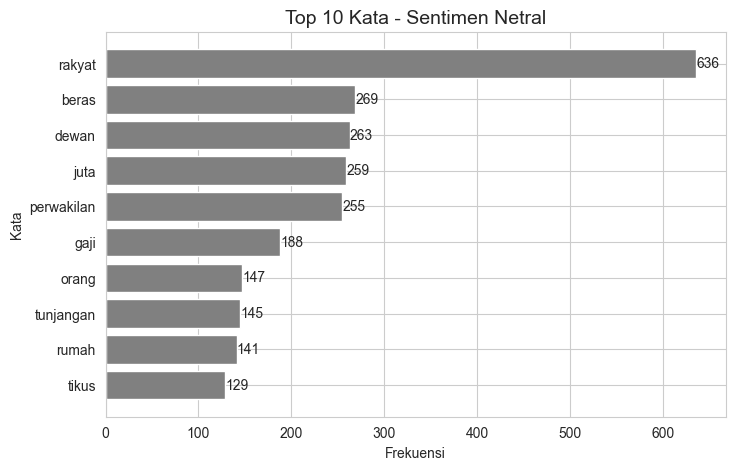

In [79]:
plot_word_freq(sentimen_Neutral, "Netral", "gray")

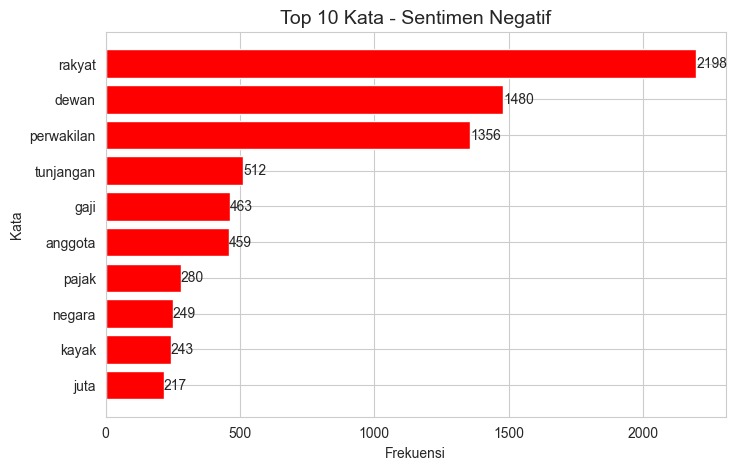

In [80]:
plot_word_freq(sentimen_Negative, "Negatif", "red")

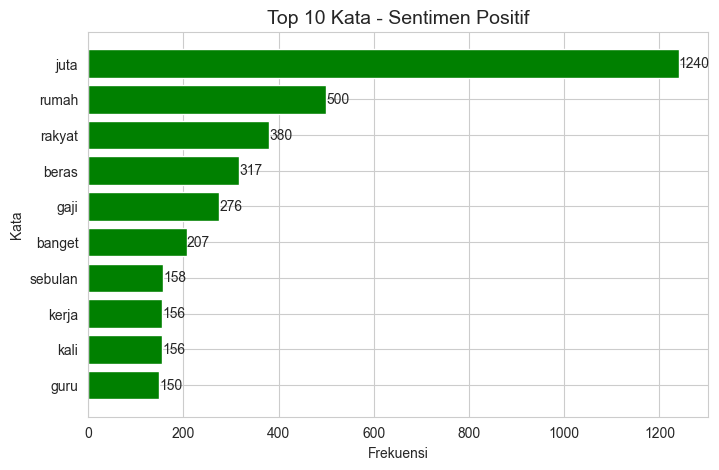

In [81]:
plot_word_freq(sentimen_Positive, "Positif", "green")

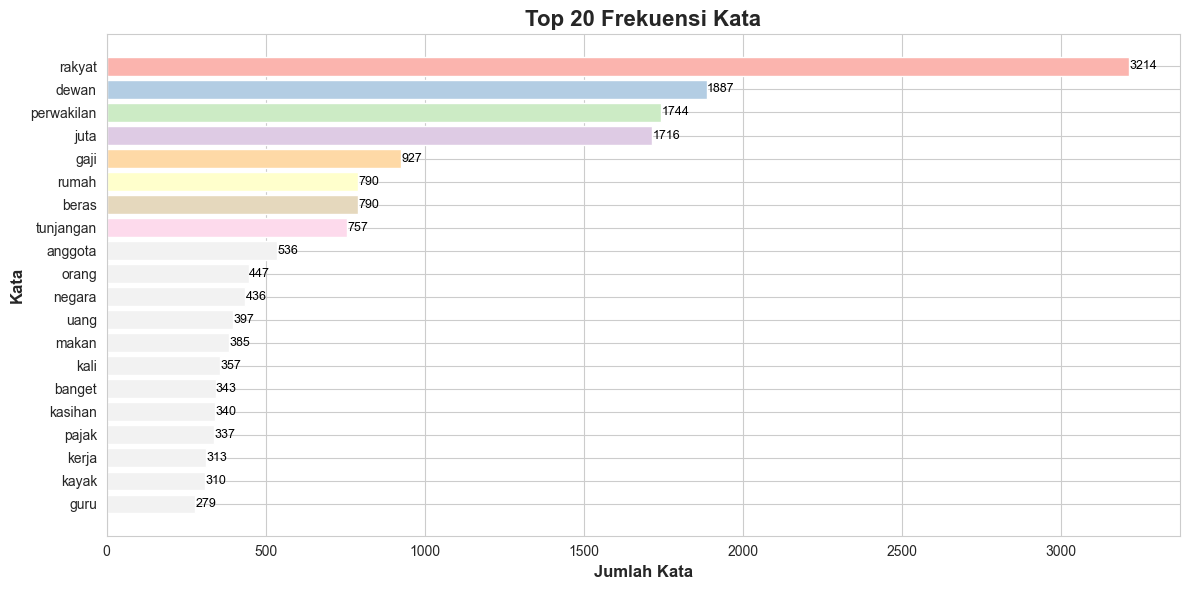

In [82]:
import matplotlib.pyplot as plt
from collections import Counter

# Gabungkan semua teks
text = " ".join(data["stopword removal"])

tokens = text.split()
word_counts = Counter(tokens)

# Ambil 20 kata teratas
top_words = word_counts.most_common(20)
word, count = zip(*top_words)

# Palet warna soft (Pastel)
colors = plt.cm.Pastel1(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.barh(word, count, color=colors)
plt.xlabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.ylabel("Kata", fontsize=12, fontweight='bold')
plt.title("Top 20 Frekuensi Kata", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # Biar frekuensi tertinggi di atas

# Tambahkan angka di ujung bar
for bar, num in zip(bars, count):
    plt.text(num + 0.5, bar.get_y() + bar.get_height()/2,
             str(num), va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()


## N-gram 

In [1]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_3class.csv")
data.info()
data.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   normalisasi       7646 non-null   str  
 1   Score             7646 non-null   int64
 2   Sentiment         7646 non-null   str  
 3   tokenize          7646 non-null   str  
 4   stopword removal  7599 non-null   str  
dtypes: int64(1), str(4)
memory usage: 298.8 KB


,normalisasi,Score,Sentiment,tokenize,stopword removal
0,serius bertanya kalau tidak ada dpr semua oran...,-3,Negatif,"['serius', 'bertanya', 'kalau', 'tidak', 'ada'...",serius dpr orang hidup
1,menari di atas penderitaan rakyat,-2,Negatif,"['menari', 'di', 'atas', 'penderitaan', 'rakyat']",menari penderitaan rakyat
2,dunia akhirat gue tidak iklas byr pajak,-2,Negatif,"['dunia', 'akhirat', 'gue', 'tidak', 'iklas', ...",dunia akhirat iklas byr pajak
3,tidak usah bayar pajak titikkkk,-3,Negatif,"['tidak', 'usah', 'bayar', 'pajak', 'titikkkk']",bayar pajak titikkkk
4,parah parah pejabat indonesiaa,-3,Negatif,"['parah', 'parah', 'pejabat', 'indonesiaa']",parah parah pejabat indonesiaa


In [2]:
data = data.dropna()
data.info()

<class 'pandas.DataFrame'>
Index: 7599 entries, 0 to 7645
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   normalisasi       7599 non-null   str  
 1   Score             7599 non-null   int64
 2   Sentiment         7599 non-null   str  
 3   tokenize          7599 non-null   str  
 4   stopword removal  7599 non-null   str  
dtypes: int64(1), str(4)
memory usage: 356.2 KB


In [3]:
data = pd.DataFrame(data[['stopword removal','Sentiment']])
data.head(5)

,stopword removal,Sentiment
0,serius dpr orang hidup,Negatif
1,menari penderitaan rakyat,Negatif
2,dunia akhirat iklas byr pajak,Negatif
3,bayar pajak titikkkk,Negatif
4,parah parah pejabat indonesiaa,Negatif


In [4]:
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

# Stopwords tambahan (bisa disesuaikan)
custom_stopwords = set(ENGLISH_STOP_WORDS)
custom_stopwords.update([
    'https', 'co', 'RT', '...', 'amp', 'lu', 'deh'])

# Fungsi buat ambil n-gram
def get_top_ngrams(corpus, n=2, top_k=10, stopwords=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stopwords).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Fungsi buat plot frekuensi n-gram
def plot_ngrams(corpus, sentiment_label, color_map=plt.cm.Set2, stopwords=None):
    top_ngrams = get_top_ngrams(corpus, n=2, top_k=10, stopwords=stopwords)
    if not top_ngrams:
        print(f"Tidak ada bigram untuk sentimen {sentiment_label}")
        return

    ngrams, counts = zip(*top_ngrams)
    colors = color_map(range(len(ngrams)))

    plt.figure(figsize=(10,6))
    bars = plt.barh(ngrams, counts, color=colors)
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Bigram - Sentimen {sentiment_label}", fontsize=16, fontweight='bold')
    plt.xlabel("Jumlah Kemunculan", fontsize=12)
    plt.ylabel("Bigram", fontsize=12)

    # Tambahin label jumlah di ujung bar
    for bar, num in zip(bars, counts):
        plt.text(num + 0.01, bar.get_y() + bar.get_height()/2,
                 str(num), va='center', fontsize=11, color='black')

    plt.tight_layout()
    plt.show()


# Ambil data per sentimen
corpus_neg = data[data['Sentiment'] == 'Negatif']['stopword removal'].astype(str).tolist()
corpus_neu = data[data['Sentiment'] == 'Netral']['stopword removal'].astype(str).tolist()
corpus_pos = data[data['Sentiment'] == 'Positif']['stopword removal'].astype(str).tolist()

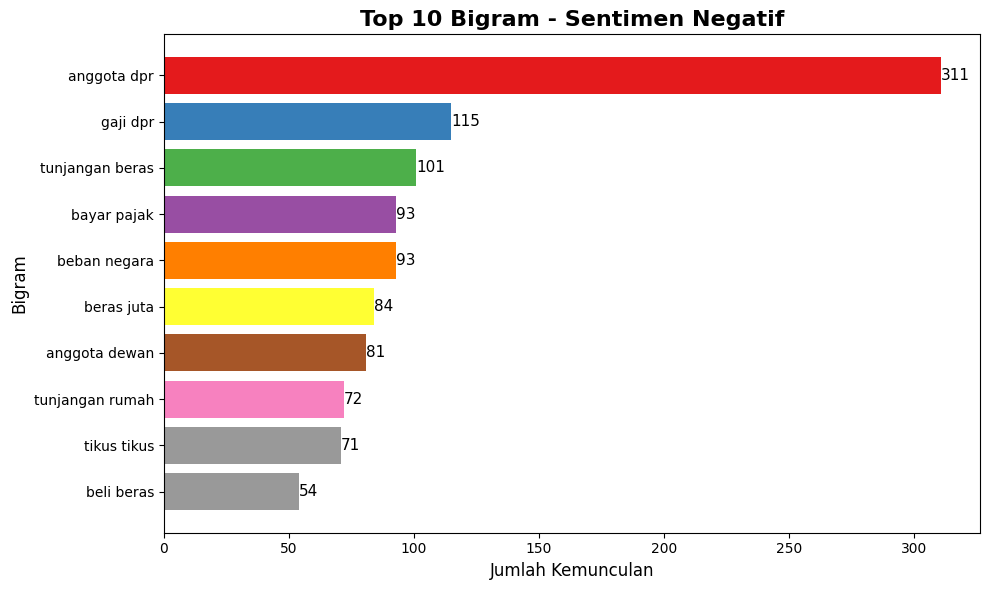

In [5]:
plot_ngrams(corpus_neg, "Negatif", plt.cm.Set1)

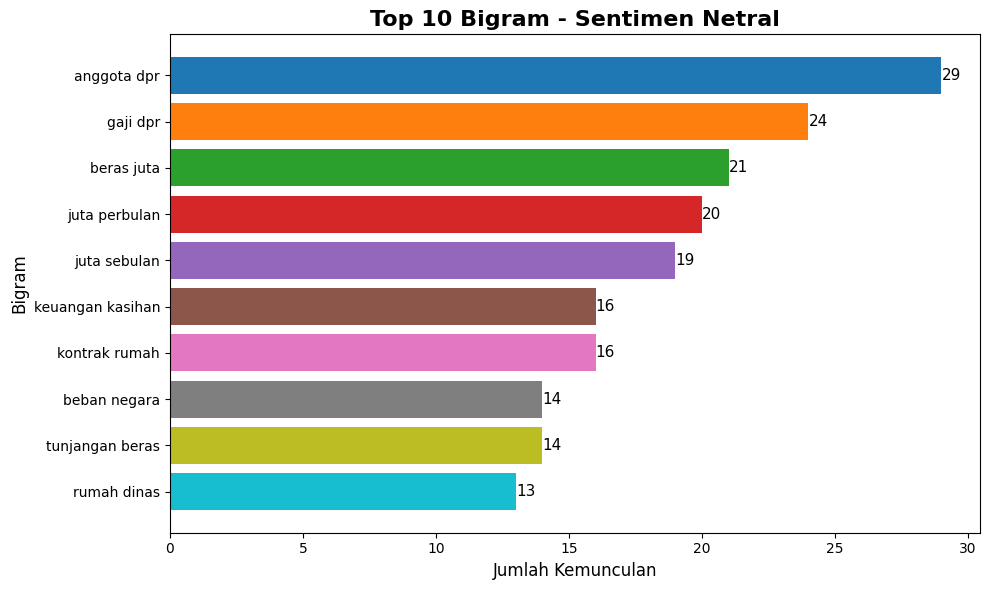

In [6]:
plot_ngrams(corpus_neu, "Netral", plt.cm.tab10)

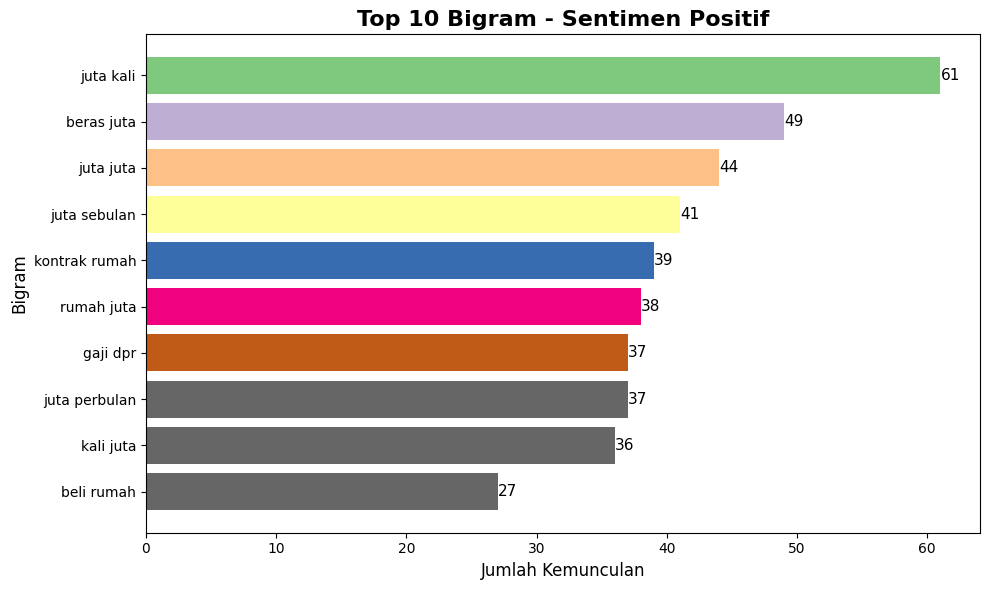

In [7]:
plot_ngrams(corpus_pos, "Positif", plt.cm.Accent)

## Bigram N-gram Berdasarkan Sentimen

Analisis bigram dipisah per kelas sentimen (Positif, Negatif, Netral) menggunakan kolom `stopword removal` dari dataset berlabel.
Bigram dipilih berdasarkan **skor kekhasan** — pasangan kata yang dominan di satu sentimen dan jarang muncul di sentimen lain,
dengan kurasi manual untuk memastikan setiap bigram benar-benar merepresentasikan karakteristik sentimen tersebut.

d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['rt'] not in stop_words.
  warnings.warn(


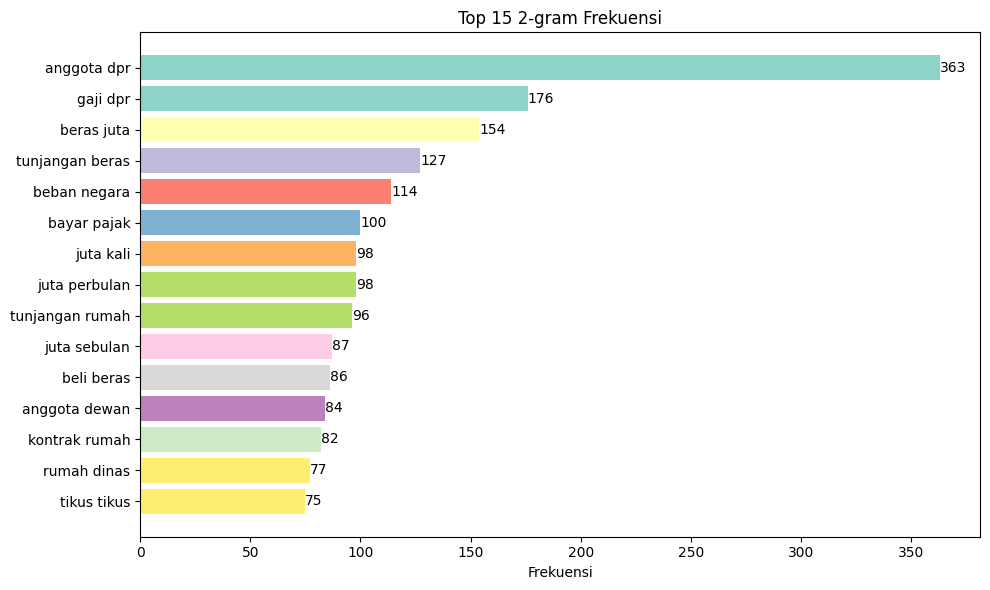

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Daftar stopwords tambahan
custom_stopwords = ['https', 'co', 'RT', '...', 'amp', 'lu', 'deh','koruptor','ai','berapa','can']

# Fungsi untuk membuat diagram batang frekuensi n-gram
def plot_ngram_frequencies(texts, ngram_range=(2,2), top_n=15, cmap=plt.cm.Set3):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=custom_stopwords)
    X = vectorizer.fit_transform(texts)

    # Hitung total frekuensi setiap n-gram
    ngram_counts = X.sum(axis=0).A1
    ngram_vocab = vectorizer.get_feature_names_out()
    freq_dist = dict(zip(ngram_vocab, ngram_counts))

    # Ambil n-gram dengan frekuensi tertinggi
    top_ngrams = Counter(freq_dist).most_common(top_n)
    labels, values = zip(*top_ngrams)

    # Buat warna berbeda untuk tiap bar
    colors = cmap(np.linspace(0, 1, len(labels)))

    # Visualisasi
    plt.figure(figsize=(10, 6))
    bars = plt.barh(labels[::-1], values[::-1], color=colors[::-1])
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Frekuensi')
    plt.xlabel('Frekuensi')

    # Tambahkan label angka di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width}', va='center')

    plt.tight_layout()
    plt.show()

# Contoh pemanggilan: Visualisasi 2-gram
plot_ngram_frequencies(data['stopword removal'], ngram_range=(2,2), top_n=15, cmap=plt.cm.Set3)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import re
from collections import Counter

# ── Load dataset berlabel ────────────────────────────────────────────────────
df_labeled = pd.read_csv('Hasil_Labelling_Data_3class.csv')
df_labeled['stopword removal'] = df_labeled['stopword removal'].fillna('')

print('Distribusi sentimen:')
print(df_labeled['Sentiment'].value_counts())

# ── Noise words: SAMA PERSIS dengan wordcloud ────────────────────────────────
# Konsistensi antara wordcloud dan bigram: kata yang dibuang di wordcloud
# juga dibuang di bigram, sehingga keduanya mencerminkan topik yang sama.
NOISE_WORDS = {
    # Angka & nominal
    'juta','ribu','ratus','miliar','milyar','triliun','persen',
    'kali','sebulan','perbulan','setahun','pertahun','perhari',
    # Kata ganti
    'aku','saya','kamu','anda','dia','kita','kami','mereka',
    'gue','gw','gua','lo','lu','loe',
    # Partikel informal
    'ya','yaa','deh','sih','nih','tuh','dong','lah','kah',
    'nah','eh','ah','oh','wah','iya','yg','nya','si',
    'wkwk','wkwkwk','haha','hehe','hihi','huhu','hahaha',
    # Penghubung & preposisi
    'dan','atau','tapi','tetapi','namun','karena','jadi',
    'maka','agar','bahwa','kalau','kalo','jika','bila',
    'dari','untuk','dengan','kepada','oleh','pada',
    'ke','di','yang','ini','itu','sana','sini','situ',
    # Keterangan umum
    'sangat','banget','sekali','paling','lebih','kurang',
    'hanya','saja','aja','cuma','juga','pun','bahkan',
    'sudah','udah','belum','masih','lagi','terus','lalu',
    'bisa','boleh','harus','perlu','mau','ingin',
    'ada','tidak','tak','bukan','jangan','tanpa',
    'ga','gak','nggak','ngga','enggak','ndak','gakk',
    # Kata terlalu umum lintas sentimen
    'orang','rakyat','negara','indonesia','pemerintah','dpr',
    'anggota','wakil','dewan','pejabat','guru',
    'gaji','tunjangan','beras','rumah','uang','kerja',
    # Kata kerja bantu
    'adalah','ialah','merupakan','menjadi',
    'buat','bikin','kasih','beri','dapat','ambil',
    'tahu','tau','bilang','kata','lihat',
    'makan','minum','pergi','datang','balik',
    # Kata umum tidak diskriminatif
    'sama','seperti','kayak','gimana','bagaimana',
    'masa','sebenarnya','harusnya','coba',
    'banyak','sedikit','semua','seluruh','setiap',
    'besar','kecil','baik','buruk','benar','salah',
    'baru','lama','dulu','sekarang','nanti',
    'sering','jarang','selalu','kadang','pernah',
    'emang','memang','apalagi','bahkan','memangnya',
    # Typo / noise
    'byr','titikkkk','indonesiaa','pejabatt',
}

def is_meaningful(word):
    """Token bermakna: bukan noise, bukan angka murni, panjang >= 4 karakter."""
    if word in NOISE_WORDS: return False
    if re.fullmatch(r'\d+', word): return False
    if re.fullmatch(r'[a-z]{1,3}', word): return False
    if len(word) < 4: return False
    return True

def get_bigram_counter(texts):
    """Hitung frekuensi bigram dengan deduplikasi teks identik."""
    text_counts = Counter(
        t.strip() for t in texts if isinstance(t, str) and t.strip()
    )
    bigram_freq     = Counter()
    bigram_doc_freq = Counter()
    for text, count in text_counts.items():
        tokens = [w for w in text.split() if is_meaningful(w)]
        bgs = list(nltk.bigrams(tokens))
        bigram_freq.update({bg: count for bg in bgs})
        bigram_doc_freq.update(set(bgs))
    return bigram_freq, bigram_doc_freq

# ── Hitung bigram per sentimen ───────────────────────────────────────────────
SENTIMENTS = ['Negatif', 'Netral', 'Positif']
freq_counters = {}
doc_counters  = {}

for sent in SENTIMENTS:
    texts = df_labeled[df_labeled['Sentiment'] == sent]['stopword removal'].tolist()
    freq_counters[sent], doc_counters[sent] = get_bigram_counter(texts)

# ── Bigram dikurasi manual — selaras dengan kata khas di wordcloud ───────────
# Negatif : kata khas wordcloud = hapus, demo, korupsi, penderitaan, pajak
# Netral  : kata khas wordcloud = mentri, keuangan, emas, aset, mewah
# Positif : kata khas wordcloud = berkah, allah, sabar, dana, kunjungan
CURATED_BIGRAMS = {
    'Negatif': [
        ('bayar',       'pajak'),          # pajak khas Negatif di wordcloud
        ('seumur',      'hidup'),          # pensiun seumur hidup = beban
        ('memikirkan',  'penderitaan'),    # penderitaan khas Negatif
        ('kolong',      'jembatan'),       # gambaran kemiskinan rakyat
        ('berbelit',    'belit'),          # kritik birokrasi berbelit
    ],
    'Netral': [
        ('mentri',      'keuangan'),       # sebutan faktual — mentri khas Netral
        ('keuangan',    'kasihan'),        # pernyataan deskriptif
        ('hidup',       'mewah'),          # mewah khas Netral di wordcloud
        ('akal',        'akalan'),         # pernyataan skeptis tanpa emosi kuat
        ('beli',        'bensin'),         # fakta biaya hidup sehari-hari
    ],
    'Positif': [
        ('kunjungan',   'dapil'),          # kunjungan khas Positif di wordcloud
        ('dana',        'aspirasi'),       # dana khas Positif
        ('allah',       'berkah'),         # berkah & allah khas Positif
        ('masuk',       'kantong'),        # apresiasi gaji masuk kantong
        ('sabar',       'semoga'),         # ekspresi dukungan/doa
    ],
}

# Ambil frekuensi aktual dari data
distinctive = {}
for sent, bigram_list in CURATED_BIGRAMS.items():
    result = []
    for bg in bigram_list:
        freq = freq_counters[sent].get(bg, 0)
        doc  = doc_counters[sent].get(bg, 0)
        result.append((bg, freq, doc))
    distinctive[sent] = result

# ── Print tabel hasil ────────────────────────────────────────────────────────
print('\n' + '='*52)
for sent in SENTIMENTS:
    print('\n  SENTIMEN ' + sent.upper())
    print('  ' + '-'*40)
    print('  ' + 'Bigram'.ljust(28) + 'Freq'.rjust(6) + '  ' + 'Doc'.rjust(5))
    print('  ' + '-'*40)
    for (w1, w2), freq, doc in distinctive[sent]:
        bg_str = w1 + ' ' + w2
        print('  ' + bg_str.ljust(28) + str(freq).rjust(6) + '  ' + str(doc).rjust(5))
print('\n' + '='*52)


Distribusi sentimen:
Sentiment
Negatif    4706
Netral     1524
Positif    1416
Name: count, dtype: int64


  SENTIMEN NEGATIF
  ----------------------------------------
  Bigram                        Freq    Doc
  ----------------------------------------
  bayar pajak                     85     84
  seumur hidup                    22     22
  memikirkan penderitaan           7      6
  kolong jembatan                  6      6
  berbelit belit                   6      6

  SENTIMEN NETRAL
  ----------------------------------------
  Bigram                        Freq    Doc
  ----------------------------------------
  mentri keuangan                 11     11
  keuangan kasihan                14     14
  hidup mewah                      3      3
  akal akalan                      3      3
  beli bensin                      5      5

  SENTIMEN POSITIF
  ----------------------------------------
  Bigram                        Freq    Doc
  ----------------------------------------
  kun

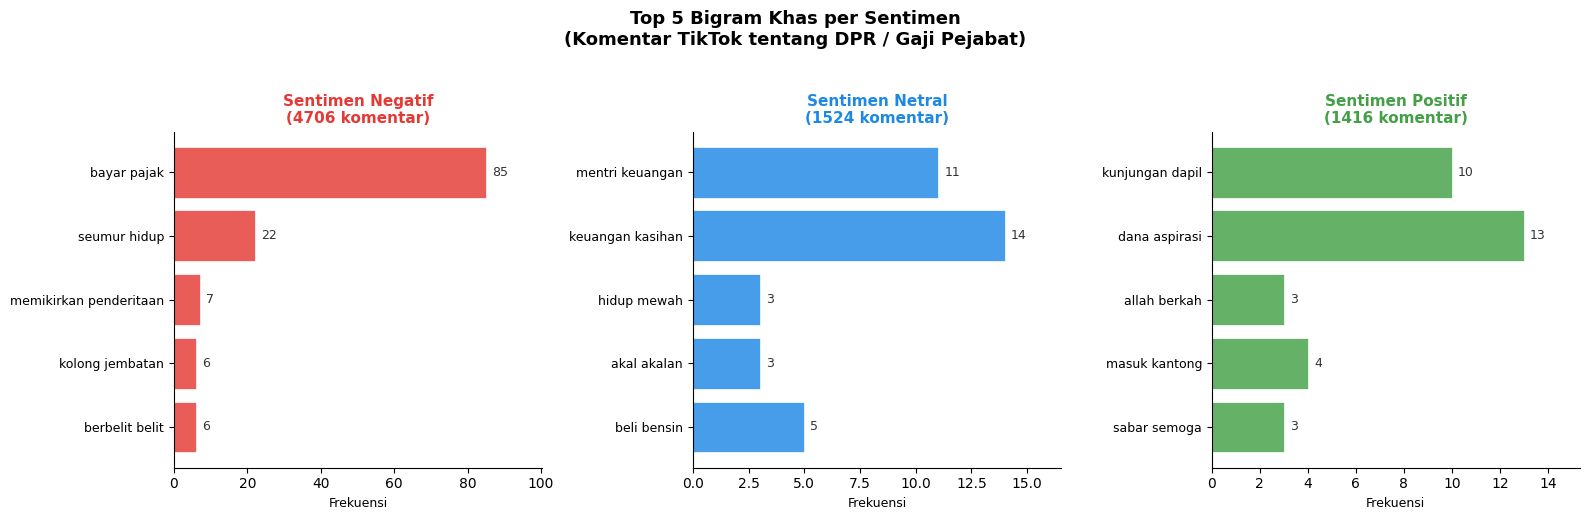

Visualisasi disimpan ke img/bigram_per_sentimen.png


In [10]:
COLORS = {
    'Negatif': '#E53935',
    'Netral' : '#1E88E5',
    'Positif': '#43A047',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Top 5 Bigram Khas per Sentimen\n(Komentar TikTok tentang DPR / Gaji Pejabat)',
    fontsize=13, fontweight='bold', y=1.03
)

for ax, sent in zip(axes, SENTIMENTS):
    data_sent = distinctive[sent]
    labels = [f"{bg[0]} {bg[1]}" for (bg, _, _) in data_sent]
    values = [freq for (_, freq, _) in data_sent]
    base_color = COLORS[sent]
    n_komentar = len(df_labeled[df_labeled['Sentiment'] == sent])

    bars = ax.barh(
        labels[::-1], values[::-1],
        color=base_color, alpha=0.82,
        edgecolor='white', linewidth=0.6
    )

    for bar, val in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + max(values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9, color='#333333'
        )

    ax.set_title(
        f'Sentimen {sent}\n({n_komentar} komentar)',
        fontsize=11, fontweight='bold', color=base_color
    )
    ax.set_xlabel('Frekuensi', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, max(values) * 1.18)

plt.tight_layout()
plt.savefig('img/bigram_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi disimpan ke img/bigram_per_sentimen.png')